In [1]:
import torch
import pandas as pd
import numpy as np
import h5py

class LSD_pretrain(torch.utils.data.Dataset):

    def __init__(self, LSD_type='toy', augmentations=None):
        self.LSD_type = LSD_type
        self.augmentations = augmentations

        if LSD_type == 'toy':
            LSD_csv_path = 'D:\GitHub\dataset\LSD\LSD_toy_metadata.csv'
            LSD_hdf5_path = 'D:\GitHub\dataset\LSD\LSD_toy_waveform_data.hdf5'

        elif LSD_type == 'small':
            raise NotImplementedError()

        else:
            raise Exception()

        self.LSD_csv = pd.read_csv(LSD_csv_path)
        self.LSD_hdf5_path = LSD_hdf5_path

    def __len__(self):
        return len(self.LSD_csv)

    def __getitem__(self, idx):

        LSD_hdf5 = h5py.File(self.LSD_hdf5_path, 'r')

        LSD_csv_sample = self.LSD_csv.iloc[[idx]]
        LSD_hdf5_sample = LSD_hdf5[LSD_csv_sample['Key'].values[0]]

        Z_wave = torch.from_numpy(LSD_hdf5_sample[:,0]).reshape(1, -1).to(dtype=torch.float32)
        N_wave = torch.from_numpy(LSD_hdf5_sample[:,1]).reshape(1, -1).to(dtype=torch.float32)
        E_wave = torch.from_numpy(LSD_hdf5_sample[:,2]).reshape(1, -1).to(dtype=torch.float32)

        length = Z_wave.shape[1]

        # [Normalization]
        # zero-center for each channel individually
        wave_list = [Z_wave, N_wave, E_wave]

        """ The code commented below is replaced by the augmentation pipeline """
        # for i, wave in enumerate(wave_list):
        #     mean = wave.mean()
        #     wave_list[i] = wave - mean
        #
        # # range to [-1,1] record amplitude
        # integrated_wave = torch.cat(wave_list, dim=0)
        # abs_min = torch.abs(integrated_wave.min())
        # abs_max = torch.abs(integrated_wave.max())
        # if abs_max > abs_min:
        #     amplitude = abs_max
        # else:
        #     amplitude = abs_min
        # integrated_wave = integrated_wave / amplitude  # normalization to [-1,1]

        integrated_wave = torch.cat(wave_list, dim=0)

        p = LSD_csv_sample['P_index'].values[0] if not pd.isnull(LSD_csv_sample['P_index'].values[0]) else np.nan
        s = LSD_csv_sample['S_index'].values[0] if not pd.isnull(LSD_csv_sample['S_index'].values[0]) else np.nan
        mag = LSD_csv_sample['Mag_value'].values[0] if not pd.isnull(LSD_csv_sample['Mag_value'].values[0]) else np.nan
        baz = LSD_csv_sample['Baz'].values[0] if not pd.isnull(LSD_csv_sample['Baz'].values[0]) else np.nan
        dis = LSD_csv_sample['Dis'].values[0] if not pd.isnull(LSD_csv_sample['Dis'].values[0]) else np.nan

        P_polarity = LSD_csv_sample['P_polarity'].values[0]
        if not pd.isnull(P_polarity):
            P_polarity = {'up': 1, 'down': 0}[P_polarity.lower()]
        pmp = P_polarity if not pd.isnull(P_polarity) else np.nan

        sample = {'data': integrated_wave, 
                'p': p, 
                's': s,
                'mag': mag,
                'baz': baz,
                'dis': dis,
                'pmp': pmp,
            }
        # print(sample)
        # augmentation for positive pair
        if self.augmentations is not None:
            q = self.augmentations(sample)  # [3, window_size]
            k = self.augmentations(sample)  # [3, window_size]
        else:
            raise Exception()

        # group the positive pair, for convenience in fetching data.
        return [q, k]
    

class LSD_finetune(torch.utils.data.Dataset):
    """
    LSD fine-tuning dataset.
    For each downstream task, the dataset is different.
    Some samples that do not have the information for the downstream task will be dropped.
    """
    def __init__(self, LSD_type='toy', augmentations=None, downstream_task='mag'):
        self.LSD_type = LSD_type
        self.augmentations = augmentations
        self.downstream_task = downstream_task

        if LSD_type == 'toy':
            LSD_csv_path = 'D:\GitHub\dataset\LSD\LSD_toy_metadata.csv'
            LSD_hdf5_path = 'D:\GitHub\dataset\LSD\LSD_toy_waveform_data.hdf5'

        elif LSD_type == 'small':
            raise NotImplementedError()

        else:
            raise Exception()

        self.LSD_csv = pd.read_csv(LSD_csv_path)
        # drop the samples that are not used for the downstream task
        if downstream_task == 'mag':
            # drop the samples that have no magnitude information
            self.LSD_csv = self.LSD_csv.dropna(subset=['Mag_value'])
        elif downstream_task == 'baz':
            # drop the samples that have no baz information
            self.LSD_csv = self.LSD_csv.dropna(subset=['Baz'])
        elif downstream_task == 'dis':
            # drop the samples that have no dis information
            self.LSD_csv = self.LSD_csv.dropna(subset=['Dis'])
        elif downstream_task == 'pmp':
            # drop the samples that have no polarity information
            self.LSD_csv = self.LSD_csv.dropna(subset=['P_polarity'])
        elif downstream_task == 'phase-picking':
            pass
        else:
            # TODO: add other downstream tasks
            raise NotImplementedError("Your downstream task is not implemented yet.")

        self.LSD_hdf5_path = LSD_hdf5_path

    def __len__(self):
        return len(self.LSD_csv)

    def __getitem__(self, idx):

        LSD_hdf5 = h5py.File(self.LSD_hdf5_path, 'r')

        LSD_csv_sample = self.LSD_csv.iloc[[idx]]
        LSD_hdf5_sample = LSD_hdf5[LSD_csv_sample['Key'].values[0]]

        Z_wave = torch.from_numpy(LSD_hdf5_sample[:,0]).reshape(1, -1).to(dtype=torch.float32)
        N_wave = torch.from_numpy(LSD_hdf5_sample[:,1]).reshape(1, -1).to(dtype=torch.float32)
        E_wave = torch.from_numpy(LSD_hdf5_sample[:,2]).reshape(1, -1).to(dtype=torch.float32)

        length = Z_wave.shape[1]

        # [Normalization]
        # zero-center for each channel individually
        wave_list = [Z_wave, N_wave, E_wave]

        integrated_wave = torch.cat(wave_list, dim=0)

        p = LSD_csv_sample['P_index'].values[0] if not pd.isnull(LSD_csv_sample['P_index'].values[0]) else np.nan
        s = LSD_csv_sample['S_index'].values[0] if not pd.isnull(LSD_csv_sample['S_index'].values[0]) else np.nan
        mag = LSD_csv_sample['Mag_value'].values[0] if not pd.isnull(LSD_csv_sample['Mag_value'].values[0]) else np.nan
        baz = LSD_csv_sample['Baz'].values[0] if not pd.isnull(LSD_csv_sample['Baz'].values[0]) else np.nan
        dis = LSD_csv_sample['Dis'].values[0] if not pd.isnull(LSD_csv_sample['Dis'].values[0]) else np.nan

        # one-hot encoding for polarity
        P_polarity = LSD_csv_sample['P_polarity'].values[0]
        if not pd.isnull(P_polarity):
            P_polarity = {'up': 1, 'down': 0}[P_polarity.lower()]
        pmp = P_polarity if not pd.isnull(P_polarity) else np.nan

        sample = {'data': integrated_wave, 
                'p': p, 
                's': s,
                'mag': mag,
                'baz': baz,
                'dis': dis,
                'pmp': pmp,
            }
        
        if self.augmentations is not None:
            sample = self.augmentations(sample)  # [3, window_size]
        else:
            raise Exception()

        if self.downstream_task == 'mag':
            label = sample['mag']
        elif self.downstream_task == 'baz':
            label = sample['baz']
        elif self.downstream_task == 'dis':
            label = sample['dis']
        elif self.downstream_task == 'pmp':
            label = sample['pmp']
            label = np.eye(2)[label]  # one-hot encoding for polarity
        elif self.downstream_task == 'phase-picking':
            print(sample['p'], sample['s'])
            label = sample['phase_picking_label']
        else:
            raise NotImplementedError("Your downstream task is not implemented yet.")
        return sample['data'], label

d:\anaconda\envs\lsd\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import augmentations
augs = [
    augmentations.NormalizeByMaxAmplitude(),
    augmentations.RandomCrop(p=1.0, window_size=3000),
    augmentations.Labelling_DPK(),
]
augs = augmentations.Compose(augs)
dataset = LSD_finetune(LSD_type='toy', augmentations=augs, downstream_task='dpk')

data, label = dataset[14156]
print(data, label)

d:\anaconda\envs\lsd\lib\site-packages\IPython\core\interactiveshell.py:3472: DtypeWarning: Columns (8,13) have mixed types.Specify dtype option on import or set low_memory=False.
  if (await self.run_code(code, result,  async_=asy)):


NotImplementedError: Your downstream task is not implemented yet.

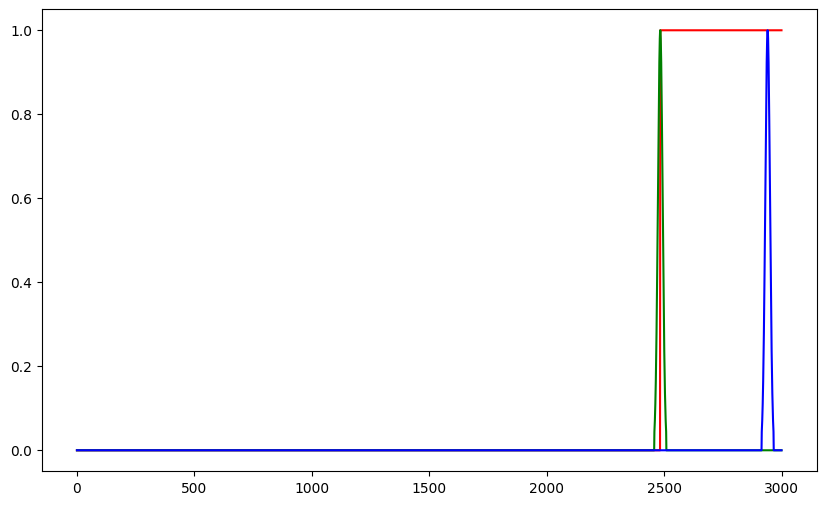

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

colors = ['r', 'g', 'b']
for i in range(3):
    plt.plot(label[i], colors[i])